In [8]:
import control as ct
import matplotlib.pyplot as plt    

In [9]:
ct.__version__

'0.9.3.post2'

In [10]:
k=1
xi=.006
wn=12.23
Gs2b=ct.tf([wn**2,0,0],[1,2*xi*wn,wn**2])#FT de angulo steper a angulo brazo
Gs2b

TransferFunction(array([149.5729,   0.    ,   0.    ]), array([1.000000e+00, 1.467600e-01, 1.495729e+02]))

In [11]:
Gs2b.pole()

array([-0.07338+12.22977986j, -0.07338-12.22977986j])

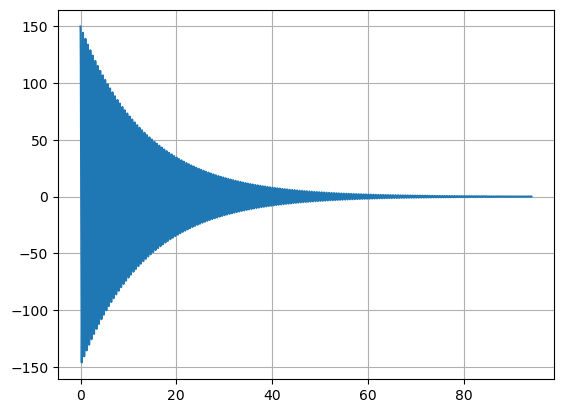

In [13]:
t,y=ct.step_response(Gs2b)
plt.plot(t,y)
plt.grid()

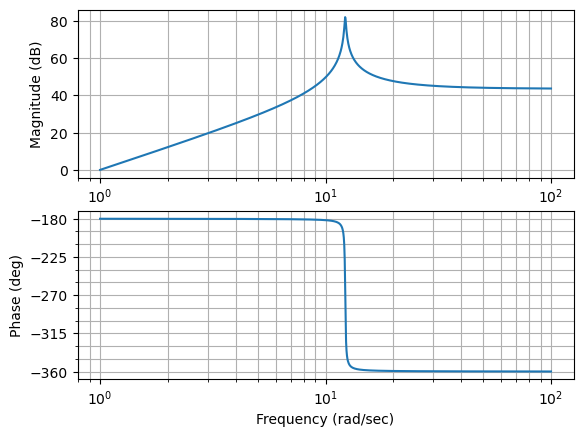

In [18]:
ct.bode(Gs2b,dB=True);

In [14]:
Gs2t=ct.parallel(Gs2b,1)
Gs2t

TransferFunction(array([1.505729e+02, 1.467600e-01, 1.495729e+02]), array([1.000000e+00, 1.467600e-01, 1.495729e+02]))

In [15]:
Gs2t.zero()

array([-0.00048734+0.9966737j, -0.00048734-0.9966737j])

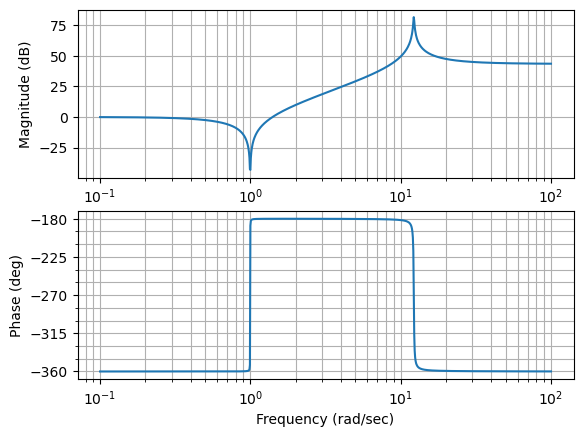

In [17]:
ct.bode(Gs2t,dB=True);

(array([[-0.07338   -12.22977986j, -0.07338   +12.22977986j],
        [-0.07338   -12.22977986j, -0.07338   +12.22977986j],
        [-0.07336257-12.22832746j, -0.07336257+12.22832746j],
        ...,
        [-0.00283871 -2.40546026j, -0.00283871 +2.40546026j],
        [-0.00072951 -1.21941703j, -0.00072951 +1.21941703j],
        [-0.00051163 -1.02120931j, -0.00051163 +1.02120931j]]),
 array([0.00000000e+00, 0.00000000e+00, 1.58832143e-06, ...,
        1.99239040e-01, 1.99239040e+00, 1.99239040e+01]))

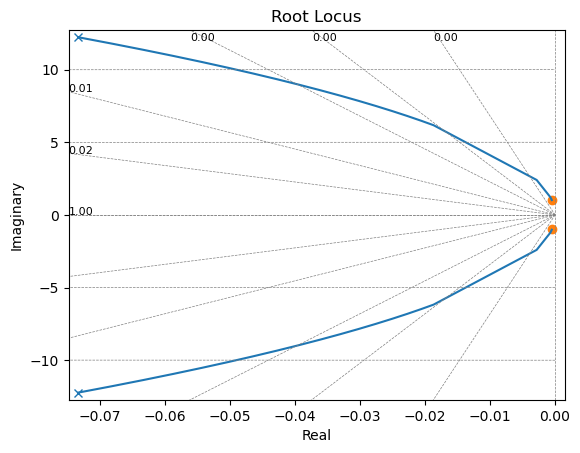

In [19]:
ct.rlocus(Gs2t)

In [23]:
D=ct.tf(Gs2t.den,Gs2t.num)*ct.tf(1,[1,0])
D


TransferFunction(array([1.000000e+00, 1.467600e-01, 1.495729e+02]), array([1.505729e+02, 1.467600e-01, 1.495729e+02, 0.000000e+00]))

In [25]:
L=D*Gs2t
L.minreal()

TransferFunction(array([1.]), array([1., 0.]))

In [30]:
ts=4
xi=.7
wn=4/ts/xi
wn
kl=1/abs(L(wn*1j))
kl

1.4285714285714286

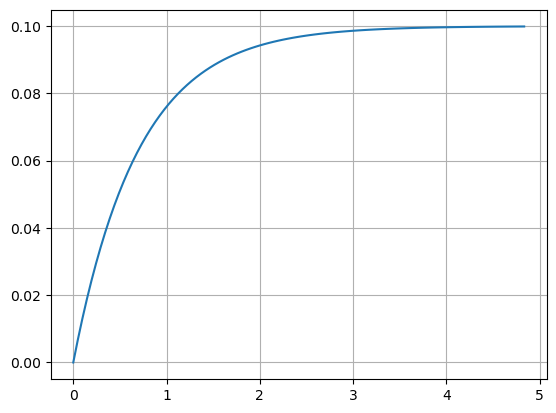

In [31]:
L=kl*L
T=ct.feedback(L)
t1,y1=ct.step_response(.1*T)
plt.plot(t1,y1)
plt.grid()

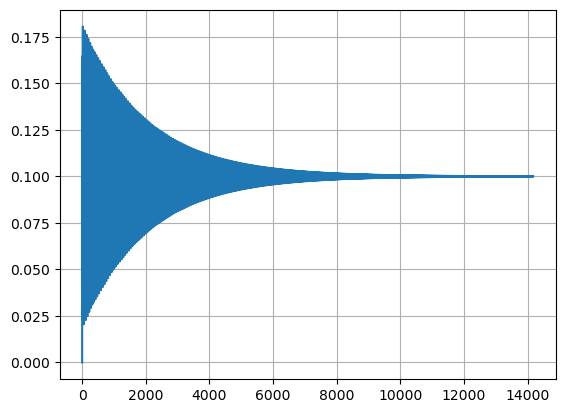

In [32]:
Tru=ct.feedback(kl*D,Gs2t)
t2,y2=ct.step_response(.1*Tru)
plt.plot(t2,y2)
plt.grid()

In [1]:
import matplotlib.animation as animation
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
M = 0.5
m = 0.2
b = 0.1
I = 0.006
g = 9.8
l = 0.3
p = I*(M+m)+M*m*l**2;
A = np.matrix([[0, 1, 0,0],
     [0, -(I+m*l**2)*b/p,  (m**2*g*l**2)/p, 0],
     [0, 0, 0,  1],
     [0, -(m*l*b)/p, m*g*l*(M+m)/p, 0]])

B =np.matrix([[0],
     [(I+m*l**2)/p],
          [0],
        [m*l/p]])

C = np.matrix([[1, 0, 0, 0],
     [0, 0, 1, 0]])

D = np.matrix([[0],
               [0]])

states = ['x', 'x_dot', 'phi', 'phi_dot']
inputs = ['u']
outputs = ['x', 'phi']

pendulo = ctrl.ss(A,B,C,D, states=states, inputs=inputs, outputs=outputs)
pendulo

<LinearIOSystem:sys[2]:['u']->['x', 'phi']>

In [5]:
ctrl.tf(pendulo.minreal())


TransferFunction([[array([ 1.81818182e+00,  1.51463674e-14, -4.45454545e+01])], [array([ 4.54545455e+00, -7.99360578e-15,  0.00000000e+00])]], [[array([ 1.00000000e+00,  1.81818182e-01, -3.11818182e+01, -4.45454545e+00,
        6.82890322e-16])], [array([  1.        ,   0.18181818, -31.18181818,  -4.45454545,
         0.        ])]])

In [ ]:
ctrl.stability_margins()